# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Fadillah Dwi Cahyanti
- **Email:** fdllhdc@gmail.com
- **ID Dicoding:** fadillahdwicahyanti

## Menentukan Pertanyaan Bisnis

- Bagaimana tren jumlah penyewaan sepeda selama periode 2011–2012?
- Musim dan kondisi cuaca seperti apa yang memiliki rata-rata jumlah penyewaan sepeda tertinggi?

## Import Semua Packages/Library yang Digunakan

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## Data Wrangling

### Gathering Data

In [6]:
day_df = pd.read_csv("data/day.csv")
hour_df = pd.read_csv("data/hour.csv")

day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Dataset harian (`day_df`) berisi ringkasan jumlah penyewaan sepeda per hari.
- Dataset per jam (`hour_df`) berisi rincian penyewaan sepeda berdasarkan jam, sehingga bisa digunakan untuk analisis pola waktu.

### Assessing Data

In [9]:
print("Informasi day_df")
print(day_df.info())
print("\nJumlah missing value day_df:")
print(day_df.isna().sum())
print("\nJumlah duplikasi day_df:", day_df.duplicated().sum())

Informasi day_df
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None

Jumlah missing value day_df:
instant       0
dteday        0
season   

In [10]:
print("Informasi hour_df")
print(hour_df.info())
print("\nJumlah missing value hour_df:")
print(hour_df.isna().sum())
print("\nJumlah duplikasi hour_df:", hour_df.duplicated().sum())

Informasi hour_df
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
None

Jumlah missing value hour

In [11]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [12]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Tidak ditemukan missing value pada kedua dataset.
- Tidak ditemukan data duplikat, sehingga data relatif bersih untuk dianalisis lebih lanjut.
- Beberapa kolom seperti `season`, `weathersit`, `yr`, dan `weekday` masih berbentuk kode numerik sehingga perlu diubah agar lebih mudah dipahami.

### Cleaning Data

In [14]:
day_clean = day_df.copy()
hour_clean = hour_df.copy()

day_clean["dteday"] = pd.to_datetime(day_clean["dteday"])
hour_clean["dteday"] = pd.to_datetime(hour_clean["dteday"])

season_map = {
    1: "Spring",
    2: "Summer",
    3: "Fall",
    4: "Winter"
}

weather_map = {
    1: "Clear",
    2: "Mist",
    3: "Light Snow/Rain",
    4: "Heavy Rain/Snow"
}

weekday_map = {
    0: "Sunday",
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday"
}

year_map = {
    0: 2011,
    1: 2012
}

for df in [day_clean, hour_clean]:
    df["season"] = df["season"].map(season_map)
    df["weathersit"] = df["weathersit"].map(weather_map)
    df["weekday"] = df["weekday"].map(weekday_map)
    df["yr"] = df["yr"].map(year_map)

day_clean.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,1,0,Saturday,0,Mist,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,1,0,Sunday,0,Mist,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,1,0,Monday,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,2011,1,0,Tuesday,1,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,2011,1,0,Wednesday,1,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Kolom tanggal sudah diubah ke format `datetime` agar mudah dianalisis berdasarkan waktu.
- Kolom kategori seperti musim, cuaca, hari, dan tahun sudah diterjemahkan ke label yang lebih informatif.
- Data siap digunakan untuk proses eksplorasi dan visualisasi.

## Exploratory Data Analysis (EDA)

### Explore ...

In [15]:
display(day_clean[["casual", "registered", "cnt"]].describe())

,casual,registered,cnt
count,731.000000,731.000000,731.000000
mean,848.176471,3656.172367,4504.348837
std,686.622488,1560.256377,1937.211452
min,2.000000,20.000000,22.000000
25%,315.500000,2497.000000,3152.000000
50%,713.000000,3662.000000,4548.000000
75%,1096.000000,4776.500000,5956.000000
max,3410.000000,6946.000000,8714.000000


In [16]:
season_rent = day_clean.groupby("season")["cnt"].mean().sort_values(ascending=False)
display(season_rent)

,cnt
season,
Fall,5644.303191
Summer,4992.331522
Winter,4728.162921
Spring,2604.132597


In [17]:
weather_rent = day_clean.groupby("weathersit")["cnt"].mean().sort_values(ascending=False)
display(weather_rent)

,cnt
weathersit,
Clear,4876.786177
Mist,4035.862348
Light Snow/Rain,1803.285714


In [18]:
weekday_rent = day_clean.groupby("weekday")["cnt"].mean().sort_values(ascending=False)
display(weekday_rent)

,cnt
weekday,
Friday,4690.288462
Thursday,4667.259615
Saturday,4550.542857
Wednesday,4548.538462
Tuesday,4510.663462
Monday,4338.123810
Sunday,4228.828571


In [19]:
hourly_rent = hour_clean.groupby("hr")["cnt"].mean()
display(hourly_rent)

,cnt
hr,
0,53.898072
1,33.375691
2,22.869930
3,11.727403
4,6.352941
5,19.889819
6,76.044138
7,212.064649
8,359.011004


**Insight:**
- Penyewaan sepeda cenderung lebih tinggi pada musim tertentu, terutama saat kondisi cuaca cerah.
- Kategori `registered` menyumbang jumlah penyewaan yang lebih besar dibanding `casual`, yang menunjukkan banyak pengguna adalah pelanggan tetap.
- Data per jam menunjukkan adanya pola penyewaan tertentu pada jam-jam sibuk.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren jumlah penyewaan sepeda selama periode 2011–2012?

/tmp/ipykernel_251/3856851719.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_rentals = day_clean.resample(rule="M", on="dteday")["cnt"].sum().reset_index()


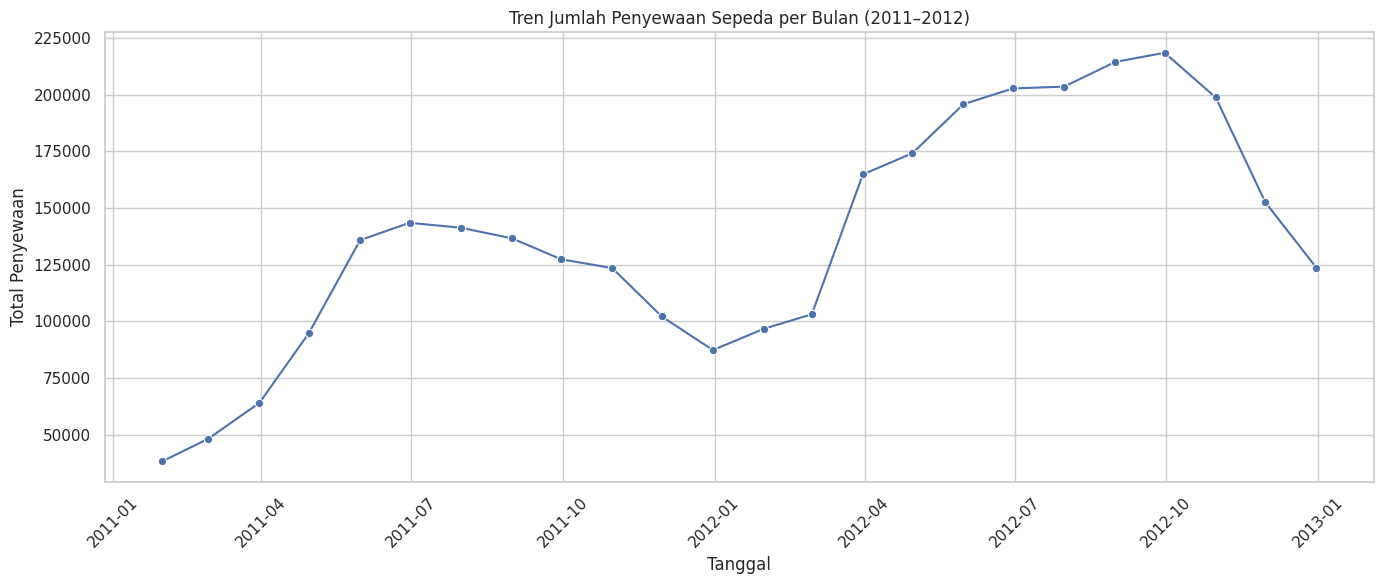

In [21]:
monthly_rentals = day_clean.resample(rule="M", on="dteday")["cnt"].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_rentals, x="dteday", y="cnt", marker="o")
plt.title("Tren Jumlah Penyewaan Sepeda per Bulan (2011–2012)")
plt.xlabel("Tanggal")
plt.ylabel("Total Penyewaan")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

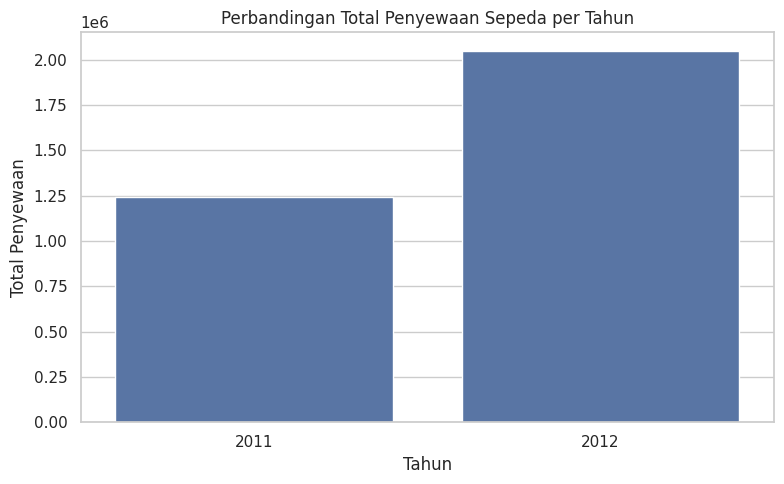

In [22]:
yearly_rentals = day_clean.groupby("yr")["cnt"].sum().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=yearly_rentals, x="yr", y="cnt")
plt.title("Perbandingan Total Penyewaan Sepeda per Tahun")
plt.xlabel("Tahun")
plt.ylabel("Total Penyewaan")
plt.tight_layout()
plt.show()

### Pertanyaan 2: Musim dan kondisi cuaca seperti apa yang memiliki rata-rata jumlah penyewaan sepeda tertinggi?

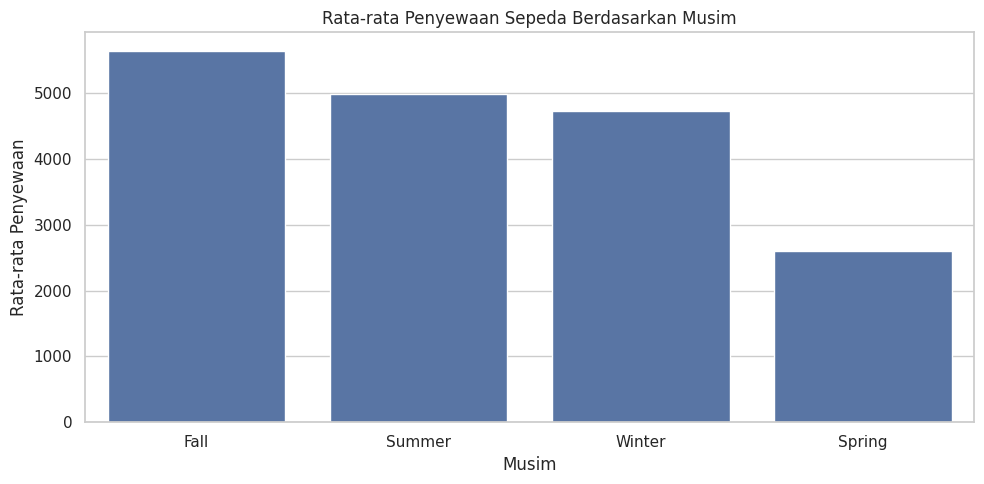

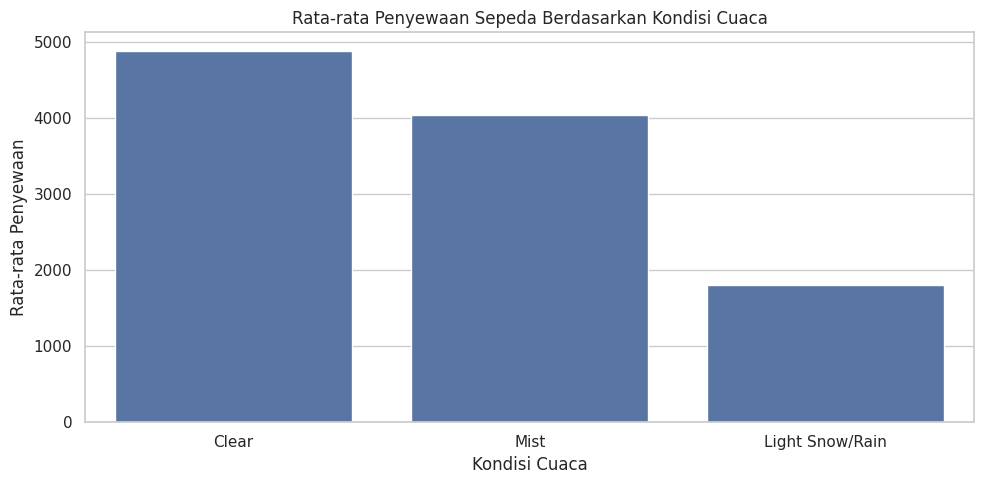

In [23]:
season_avg = day_clean.groupby("season")["cnt"].mean().sort_values(ascending=False).reset_index()
weather_avg = day_clean.groupby("weathersit")["cnt"].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=season_avg, x="season", y="cnt")
plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Musim")
plt.xlabel("Musim")
plt.ylabel("Rata-rata Penyewaan")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=weather_avg, x="weathersit", y="cnt")
plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Rata-rata Penyewaan")
plt.tight_layout()
plt.show()

**Insight:**
- Jumlah penyewaan sepeda menunjukkan tren meningkat dari tahun 2011 ke 2012.
- Secara bulanan, penyewaan cenderung naik pada pertengahan tahun dan menurun pada awal atau akhir tahun.
- Musim dengan rata-rata penyewaan tertinggi adalah **Fall** dan **Summer**, sedangkan kondisi cuaca **Clear** menghasilkan rata-rata penyewaan tertinggi.
- Cuaca buruk seperti hujan atau salju ringan menurunkan jumlah penyewaan secara cukup signifikan.

## Analisis Lanjutan (Opsional)

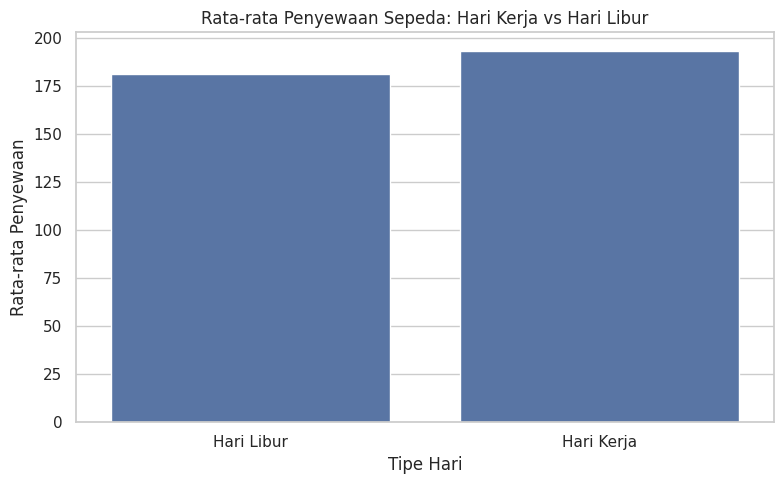

In [25]:
day_type_rent = hour_clean.groupby("workingday")["cnt"].mean().reset_index()
day_type_rent["workingday"] = day_type_rent["workingday"].map({
    0: "Hari Libur",
    1: "Hari Kerja"
})

plt.figure(figsize=(8,5))
sns.barplot(data=day_type_rent, x="workingday", y="cnt")
plt.title("Rata-rata Penyewaan Sepeda: Hari Kerja vs Hari Libur")
plt.xlabel("Tipe Hari")
plt.ylabel("Rata-rata Penyewaan")
plt.tight_layout()
plt.show()

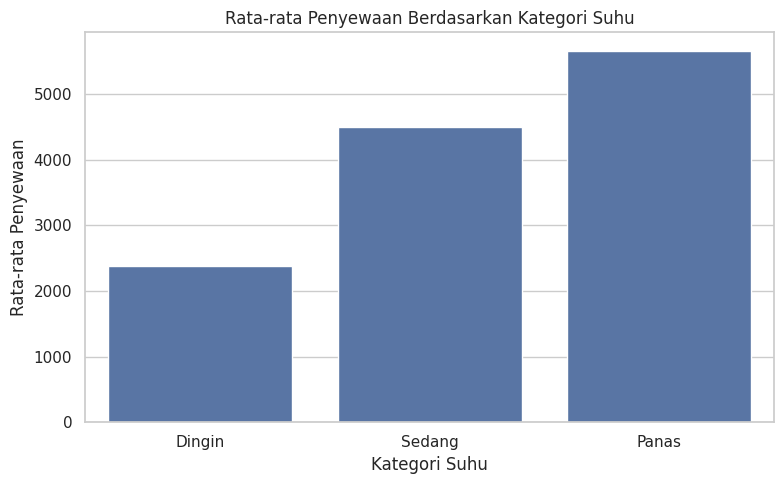

In [26]:
day_clean["temp_category"] = pd.cut(
    day_clean["temp"],
    bins=[0, 0.3, 0.6, 1.0],
    labels=["Dingin", "Sedang", "Panas"]
)

temp_rent = day_clean.groupby("temp_category", observed=False)["cnt"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=temp_rent, x="temp_category", y="cnt")
plt.title("Rata-rata Penyewaan Berdasarkan Kategori Suhu")
plt.xlabel("Kategori Suhu")
plt.ylabel("Rata-rata Penyewaan")
plt.tight_layout()
plt.show()

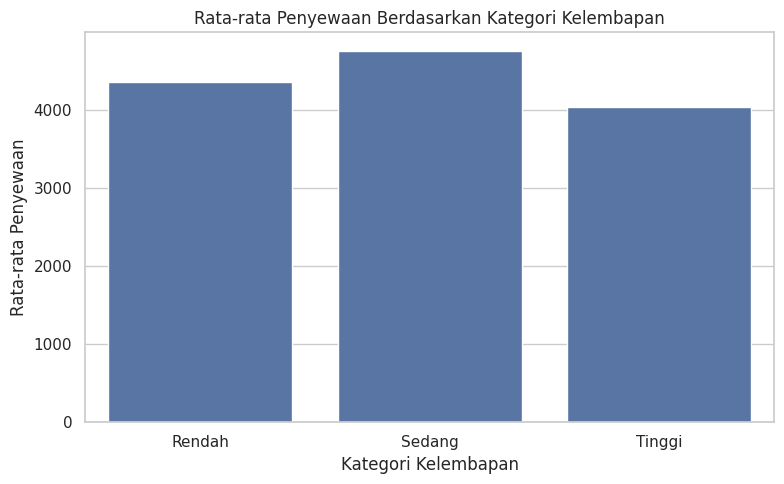

In [27]:
day_clean["hum_category"] = pd.cut(
    day_clean["hum"],
    bins=[0, 0.4, 0.7, 1.0],
    labels=["Rendah", "Sedang", "Tinggi"]
)

hum_rent = day_clean.groupby("hum_category", observed=False)["cnt"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=hum_rent, x="hum_category", y="cnt")
plt.title("Rata-rata Penyewaan Berdasarkan Kategori Kelembapan")
plt.xlabel("Kategori Kelembapan")
plt.ylabel("Rata-rata Penyewaan")
plt.tight_layout()
plt.show()

**Insight:**

- Penyewaan sepeda menunjukkan pola yang berbeda antara hari kerja dan hari libur. Pada hari kerja, penyewaan cenderung meningkat pada jam-jam sibuk seperti pagi dan sore hari yang kemungkinan berkaitan dengan aktivitas perjalanan kerja.
- Pada hari libur, pola penyewaan sepeda lebih merata sepanjang hari karena lebih banyak digunakan untuk aktivitas rekreasi.
- Analisis kategori suhu menunjukkan bahwa suhu sedang hingga hangat menghasilkan rata-rata penyewaan sepeda yang lebih tinggi dibandingkan suhu dingin.
- Hal ini mengindikasikan bahwa kenyamanan suhu lingkungan turut mempengaruhi keputusan pengguna untuk menggunakan layanan bike sharing.

## Conclusion

- Conclusion Pertanyaan 1: Bagaimana tren jumlah penyewaan sepeda selama periode 2011–2012?

Tren penyewaan sepeda selama periode 2011–2012 menunjukkan peningkatan. Total penyewaan sepeda pada tahun 2012 lebih tinggi dibandingkan tahun 2011, yang menunjukkan bahwa layanan bike sharing semakin banyak digunakan oleh masyarakat. Selain itu, secara bulanan terlihat bahwa jumlah penyewaan cenderung meningkat pada pertengahan tahun dan menurun pada awal maupun akhir tahun.

- Conclusion Pertanyaan 2: Musim dan kondisi cuaca seperti apa yang memiliki rata-rata jumlah penyewaan sepeda tertinggi?

Faktor musim dan kondisi cuaca memiliki pengaruh terhadap jumlah penyewaan sepeda. Musim Fall dan Summer memiliki rata-rata jumlah penyewaan tertinggi. Selain itu, kondisi cuaca cerah menghasilkan jumlah penyewaan yang lebih tinggi dibandingkan kondisi cuaca yang kurang baik seperti hujan atau salju ringan.
